In [2]:
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# from google.colab import drive
# drive.mount('/content/drive')
import h5py
import numpy as np
from timeit import default_timer
import operator
from datetime import date
# !pip install pydmd
# from pydmd import OptDMD, DMD
from scipy.linalg import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path

This file contains scripts that effectively recreate the existing plots in the arXiv paper.

Ok, this shows what files there are... Should be 3 per speed for each model

In [3]:
# which runs to load, newest per model unless RUN_SELECT is set
speed = "5Hz_200fps"

OUTPUT_ROOT = Path("./outputs")

# label shown in plots  ->  outputs/<subdirectory>
MODELS = {
    "Baseline (UNet)": "UNet",
    "UNet + PITA":     "UNet+PITA",
    "UNet + adv-NO":   "UNet+advNO",
}

# part of a filename to pick a specific run, None = most recent
RUN_SELECT = {
    "Baseline (UNet)": None,
    "UNet + PITA":     None,
    "UNet + adv-NO":   None,
}

# plot styles
MODEL_STYLE = {
    "Baseline (UNet)": dict(color="C0", marker="o", ls="--"),
    "UNet + PITA":     dict(color="C1", marker="s", ls="--"),
    "UNet + adv-NO":   dict(color="C2", marker="^", ls="-"),
}
TRUTH_STYLE = dict(color="black", ls="-", lw=2.2)

# old output folder
LEGACY_DIRS = [Path("./UNet Output")]
LEGACY_TAGS = {"UNet": "BASELINE_NO_PITA", "UNet+PITA": "BASELINE_WITH_PITA",
               "UNet+advNO": "BASELINE_ADV_NO"}


def list_runs(label):
    subdir = MODELS[label]
    files = sorted((OUTPUT_ROOT / subdir).glob(f"*{speed}*.h5"))
    if not files:
        tag = LEGACY_TAGS.get(subdir, subdir)
        for d in LEGACY_DIRS:
            files += sorted(d.glob(f"*{speed}*{tag}*.h5"))
    return files


def find_run(label):
    files = list_runs(label)
    sel = (RUN_SELECT.get(label) or "").strip()
    if sel:
        files = [f for f in files if sel in f.name]
        if not files:
            avail = "\n  ".join(f.name for f in list_runs(label)) or "(none)"
            raise FileNotFoundError(
                f"{label}: no run matching RUN_SELECT {sel!r} in "
                f"outputs/{MODELS[label]}/.  Available:\n  {avail}")
    if not files:
        raise FileNotFoundError(
            f"{label}: no runs found in outputs/{MODELS[label]}/. "
            f"Run the training + save cells for this model first.")
    h5 = files[-1]
    pt = h5.with_suffix(".pt")
    return h5, (pt if pt.exists() else None)


def show_available():
    print(f"{'model':<18}  {'runs':>4}  selected")
    print("=" * 78)
    for label in MODELS:
        available = list_runs(label)
        try:
            h5, _ = find_run(label)
            pin = f"  [pinned: {RUN_SELECT[label]}]" if RUN_SELECT.get(label) else ""
            print(f"{label:<18}  {len(available):>4}  {h5.name}{pin}")
        except FileNotFoundError as e:
            print(f"{label:<18}  {len(available):>4}  !! {str(e).splitlines()[0]}")
    print("=" * 78)

show_available()

model               runs  selected
Baseline (UNet)        4  20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA            3  20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO          3  20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5


Ok, here's some functions to make loading data easier

In [4]:
def load_run(label):
    # load a run and un-normalize, arrays are [C, B, H, W, T+1]
    h5, pt = find_run(label)
    with h5py.File(h5, "r") as f:
        a, p = f["u_actual"][:], f["u_pred"][:]
        ux_m, ux_s = f["u_x_mean"][()], f["u_x_std"][()]
        uy_m, uy_s = f["u_y_mean"][()], f["u_y_std"][()]
        meta = dict(f.attrs)
        losses = (f["train_losses"][:], f["test_losses"][:])
    assert a.shape[0] == 2 and p.shape[0] == 2, "expected [C=2, B, H, W, T+1]"
    a[0] = a[0] * ux_s + ux_m;  a[1] = a[1] * uy_s + uy_m
    p[0] = p[0] * ux_s + ux_m;  p[1] = p[1] * uy_s + uy_m
    return dict(label=label, h5=h5, pt=pt, act=a, pred=p, meta=meta, losses=losses,
                stats=dict(u_x_mean=ux_m, u_x_std=ux_s, u_y_mean=uy_m, u_y_std=uy_s))


def get_u_diff_norm(u_act, u_pred, num_steps=10):
    u_diff = []
    for i in range(num_steps):
        u_diff.append(np.linalg.norm(u_act[..., i+1] - u_pred[..., i+1]) / np.linalg.norm(u_act[..., i+1]))
    return u_diff

Ok, let's load in some data to make some sample plots

In [5]:
_r = load_run("Baseline (UNet)")
unet_act, unet_pred = _r["act"], _r["pred"]
print(f"loaded {_r['h5'].name}  ->  {unet_act.shape}  [C, B, H, W, T+1]")

loaded 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5  ->  (2, 48, 133, 89, 11)  [C, B, H, W, T+1]


## Model comparison: Baseline vs. PITA vs. adv-NO

Uses the newest run per model unless `RUN_SELECT` is set.

In [6]:
show_available()


model               runs  selected
Baseline (UNet)        4  20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA            3  20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO          3  20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5


In [7]:
runs = {}
for label in MODELS:
    try:
        runs[label] = load_run(label)
        r = runs[label]
        print(f"{label:<18}  pred {r['pred'].shape}  <- {r['h5'].name}")
    except FileNotFoundError as e:
        print(f"{label:<18}  SKIPPED - {str(e).splitlines()[0]}")

assert runs, "No runs loaded. Train at least one model and run its save cell."

# all runs should use the same test data
_ref = next(iter(runs.values()))
for r in runs.values():
    assert r["act"].shape == _ref["act"].shape, (r["label"], r["act"].shape)

print(f"\nloaded {len(runs)} model(s); arrays are [C, B, H, W, T+1] = {_ref['act'].shape}")

Baseline (UNet)     pred (2, 48, 133, 89, 11)  <- 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.h5
UNet + PITA         pred (2, 48, 133, 89, 11)  <- 20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.h5
UNet + adv-NO       pred (2, 48, 133, 89, 11)  <- 20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.h5

loaded 3 model(s); arrays are [C, B, H, W, T+1] = (2, 48, 133, 89, 11)


In [8]:
# re-run the saved models past the saved horizon if ROLLOUT_T is longer
ROLLOUT_T = 30

SEED, NTEST = 5496, 48  # same as training notebook
DATA_FILE   = "./.data/Re_2520.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_test_split(stats):
    # rebuild the normalized test split from training
    with h5py.File(DATA_FILE, "r") as f:
        u_x, u_y = f["u_x"][:], f["u_y"][:]
    # same axis order as MatReader, then [N, H, W, T]
    u_x = np.transpose(u_x, axes=range(u_x.ndim - 1, -1, -1)).astype(np.float32)
    u_y = np.transpose(u_y, axes=range(u_y.ndim - 1, -1, -1)).astype(np.float32)
    u_x = np.transpose(u_x, (3, 0, 1, 2)); u_y = np.transpose(u_y, (3, 0, 1, 2))

    state = np.random.get_state()
    np.random.seed(SEED)
    p = np.random.permutation(len(u_x))
    np.random.set_state(state)
    u_x, u_y = u_x[p][-NTEST:], u_y[p][-NTEST:]

    x_n = (u_x - stats["u_x_mean"]) / stats["u_x_std"]
    y_n = (u_y - stats["u_y_mean"]) / stats["u_y_std"]
    return x_n, y_n


def rollout_ckpt(ckpt, u0, num_steps):
    model = torch.load(ckpt, map_location=device, weights_only=False).eval()
    preds, u = [u0], u0
    with torch.no_grad():
        for _ in range(num_steps):
            u = model(u)
            preds.append(u)
    return torch.stack(preds, dim=1).permute(2, 0, 3, 4, 1).cpu().numpy()


T_saved = _ref["pred"].shape[-1] - 1
if ROLLOUT_T <= T_saved:
    act_L = _ref["act"][..., : ROLLOUT_T + 1]
    pred_L = {lab: r["pred"][..., : ROLLOUT_T + 1] for lab, r in runs.items()}
    print(f"using saved rollout, sliced to t = {ROLLOUT_T}")
else:
    print(f"saved horizon is t = {T_saved}; re-rolling checkpoints to t = {ROLLOUT_T}")
    stats = _ref["stats"]
    x_n, y_n = load_test_split(stats)
    u0 = torch.from_numpy(np.stack([x_n[..., 0], y_n[..., 0]], axis=1)).to(device)

    pred_L = {}
    for lab, r in runs.items():
        assert r["pt"] is not None, f"{lab}: no .pt checkpoint next to {r['h5'].name}"
        print(f"  rolling out {r['pt'].name}")
        p = rollout_ckpt(r["pt"], u0, ROLLOUT_T)
        p[0] = p[0] * stats["u_x_std"] + stats["u_x_mean"]
        p[1] = p[1] * stats["u_y_std"] + stats["u_y_mean"]
        pred_L[lab] = p

    act_L = np.stack([x_n[..., : ROLLOUT_T + 1], y_n[..., : ROLLOUT_T + 1]], axis=0)
    act_L[0] = act_L[0] * stats["u_x_std"] + stats["u_x_mean"]
    act_L[1] = act_L[1] * stats["u_y_std"] + stats["u_y_mean"]

    # check against the saved rollout
    n_saved = T_saved + 1
    assert np.abs(act_L[..., :n_saved] - _ref["act"]).max() < 1e-3
    for lab, r in runs.items():
        assert np.abs(pred_L[lab][..., :n_saved] - r["pred"]).max() < 1e-2, lab

print(f"comparison arrays -> truth {act_L.shape}, {len(pred_L)} predictions  [C, B, H, W, T+1]")

saved horizon is t = 10; re-rolling checkpoints to t = 30
  rolling out 20260907-211749_UNet_200epoch_bs16_5Hz_200fps_BASELINE_NO_PITA.pt
  rolling out 20260907-211757_UNet+PITA_200epoch_bs16_5Hz_200fps_BASELINE_WITH_PITA.pt
  rolling out 20260907-211805_UNet+advNO_200epoch_bs16_5Hz_200fps_BASELINE_ADV_NO.pt
comparison arrays -> truth (2, 48, 133, 89, 31), 3 predictions  [C, B, H, W, T+1]


### Figure A: per-timestep relative-L2 error (log scale)

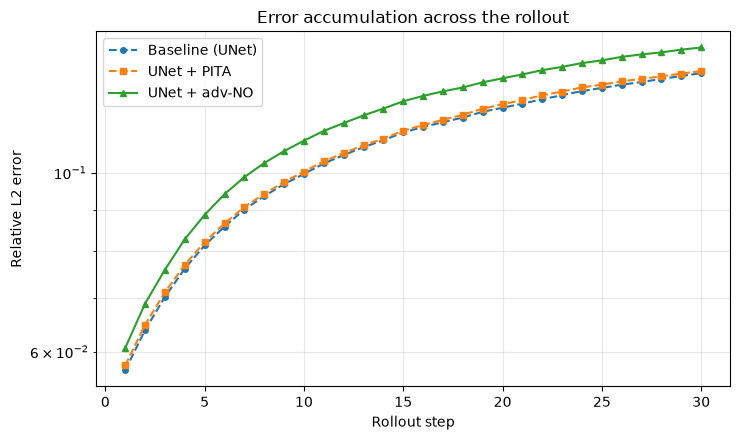

Baseline (UNet)     t=1: 0.0569   t=10: 0.0996   t=30: 0.1329
UNet + PITA         t=1: 0.0577   t=10: 0.1003   t=30: 0.1337
UNet + adv-NO       t=1: 0.0606   t=10: 0.1096   t=30: 0.1430


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
horizons = np.arange(1, ROLLOUT_T + 1)
err_curves = {}
for lab, pred in pred_L.items():
    e = get_u_diff_norm(act_L, pred, num_steps=ROLLOUT_T)
    err_curves[lab] = np.asarray(e)
    ax.plot(horizons, e, label=lab, markersize=4, **MODEL_STYLE[lab])
ax.set_yscale("log")
ax.set_xlabel("Rollout step")
ax.set_ylabel("Relative L2 error")
ax.set_title("Error accumulation across the rollout")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for lab, e in err_curves.items():
    print(f"{lab:<18}  t=1: {e[0]:.4f}   t=10: {e[min(9, len(e)-1)]:.4f}   t={ROLLOUT_T}: {e[-1]:.4f}")

### Figure B: velocity-field snapshots

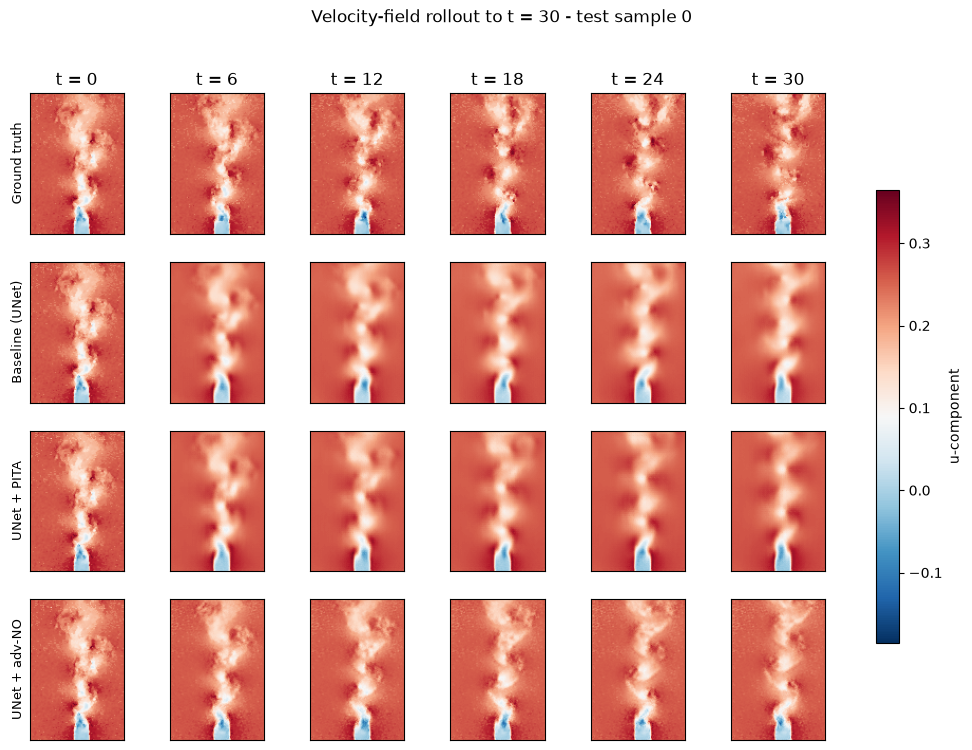

In [10]:
def plot_field_grid(rows, horizons, cmap, vmin, vmax, cbar_label, title):
    fig, axes = plt.subplots(len(rows), len(horizons),
                             figsize=(2.2 * len(horizons), 2.1 * len(rows)), squeeze=False)
    for r, (label, field) in enumerate(rows):
        for c, t in enumerate(horizons):
            ax = axes[r][c]
            im = ax.imshow(field[..., t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0: ax.set_title(f"t = {t}")
            if c == 0: ax.set_ylabel(label, fontsize=9)
    fig.colorbar(im, ax=axes, shrink=0.7, label=cbar_label)
    fig.suptitle(title)
    plt.show()

sample_idx = 0
component  = 0
horizons_L = list(range(0, ROLLOUT_T + 1, max(1, ROLLOUT_T // 5)))

rows = [("Ground truth", act_L[component, sample_idx])]
rows += [(lab, pred_L[lab][component, sample_idx]) for lab in pred_L]

gt_show = rows[0][1][..., horizons_L]
plot_field_grid(rows, horizons_L, cmap="RdBu_r",
                vmin=float(gt_show.min()), vmax=float(gt_show.max()),
                cbar_label="u-component",
                title=f"Velocity-field rollout to t = {ROLLOUT_T} - test sample {sample_idx}")

### Figure C: prediction error vs. ground truth

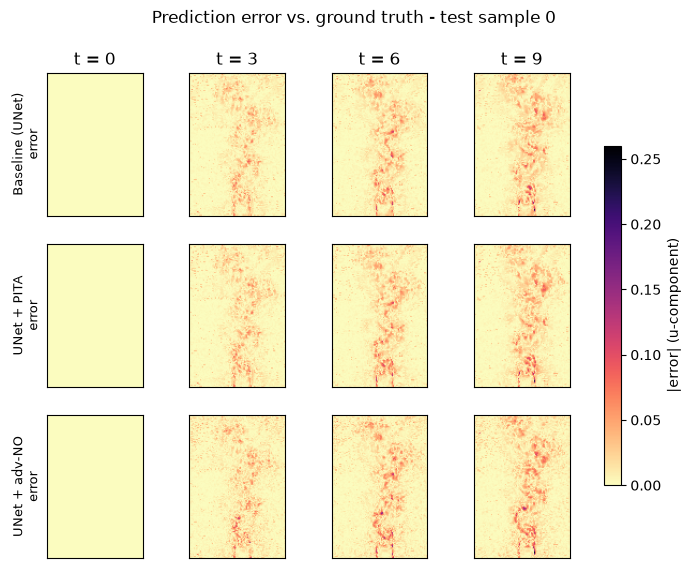

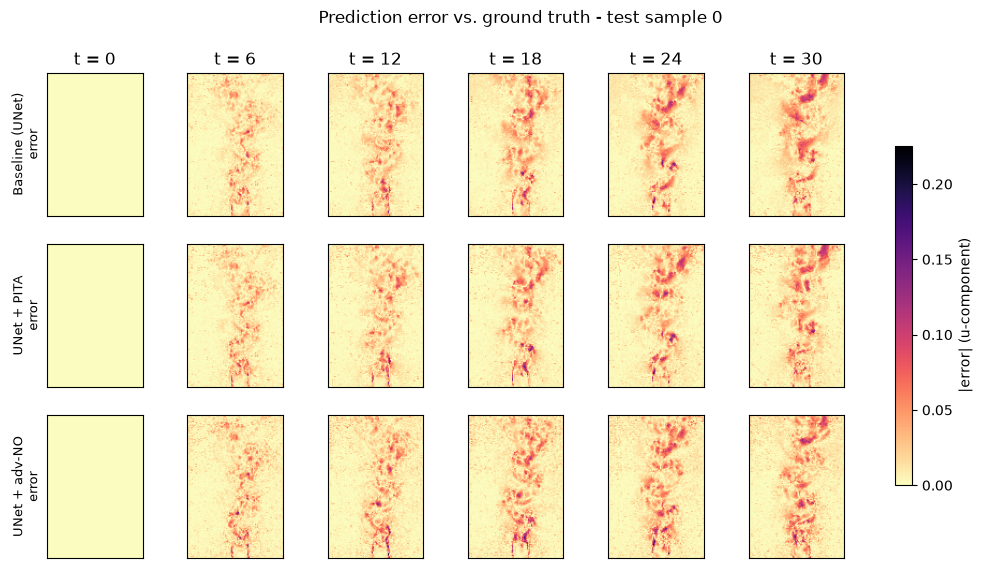

In [11]:
def plot_error_comparison(horizons, sample_idx=0, component=0):
    gt = act_L[component, sample_idx]
    rows = [(f"{lab}\nerror", np.abs(gt - pred_L[lab][component, sample_idx])) for lab in pred_L]
    vmax = max(float(field[..., horizons].max()) for _, field in rows)
    plot_field_grid(rows, horizons, cmap="magma_r", vmin=0, vmax=vmax,
                    cbar_label="|error| (u-component)",
                    title=f"Prediction error vs. ground truth - test sample {sample_idx}")

plot_error_comparison([0, 3, 6, 9])                # short horizon
plot_error_comparison(horizons_L)                  # full horizon, up to ROLLOUT_T

### Figure D: spectral bias, energy spectra

In [12]:
def energy_spectrum(field, nbins=40):
    # radially binned energy spectrum of one [H, W] field, k=0 bin dropped
    H, W = field.shape
    power = np.abs(np.fft.fft2(field))**2 / (H * W)

    ky = np.fft.fftfreq(H)
    kx = np.fft.fftfreq(W)
    KX, KY = np.meshgrid(kx, ky)
    k = np.sqrt(KX**2 + KY**2)

    bins = np.linspace(0, 0.5, nbins + 1)
    E_sum, edges = np.histogram(k, bins=bins, weights=power)
    counts, _    = np.histogram(k, bins=bins)
    E = E_sum / np.maximum(counts, 1)
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers[1:], E[1:]


def avg_spectrum(arr, t, n_samples=48):
    # spectrum averaged over samples and u, v
    Es = []
    n_samples = min(n_samples, arr.shape[1])
    for s in range(n_samples):
        for c in (0, 1):
            k, E = energy_spectrum(arr[c, s, :, :, t])
            Es.append(E)
    return k, np.mean(Es, axis=0)


# check
_k_test = np.sqrt(np.add.outer(np.fft.fftfreq(133)**2, np.fft.fftfreq(89)**2))
assert _k_test[0, 0] == 0.0
assert abs(_k_test.max() - 0.707) < 0.01

# truth vs truth at nearby times should be ~1
_k, _E0 = avg_spectrum(act_L, 0)
_,  _E5 = avg_spectrum(act_L, 5)
print(f"control: truth t0/t5 spectrum ratio, median = {np.median(_E0/_E5):.2f}")

control: truth t0/t5 spectrum ratio, median = 1.00


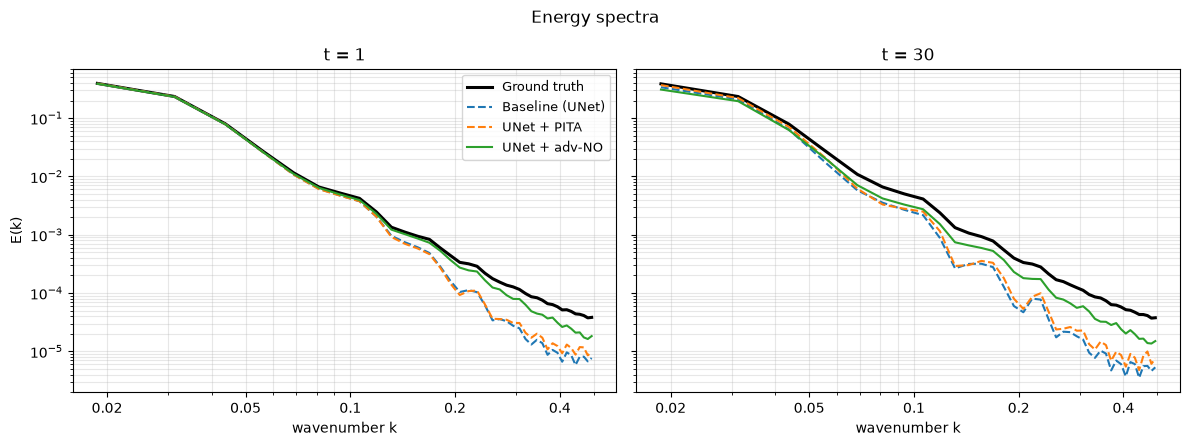

t= 1  energy ratio vs truth (1.00 = perfect)
       Baseline (UNet)    low-k: 0.97   high-k: 0.17
       UNet + PITA        low-k: 0.97   high-k: 0.23
       UNet + adv-NO      low-k: 0.98   high-k: 0.50
t=30  energy ratio vs truth (1.00 = perfect)
       Baseline (UNet)    low-k: 0.75   high-k: 0.12
       UNet + PITA        low-k: 0.82   high-k: 0.17
       UNet + adv-NO      low-k: 0.76   high-k: 0.40


In [13]:
# energy spectra, early and late
t_early, t_late = 1, ROLLOUT_T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, t in zip(axes, (t_early, t_late)):
    k, E = avg_spectrum(act_L, t)
    ax.loglog(k, E, label="Ground truth", **TRUTH_STYLE)
    for lab, pred in pred_L.items():
        k, E = avg_spectrum(pred, t)
        st = MODEL_STYLE[lab]
        ax.loglog(k, E, color=st["color"], ls=st["ls"], label=lab)
    ax.set_title(f"t = {t}")
    ax.set_xlabel("wavenumber k")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.4], ["0.02", "0.05", "0.1", "0.2", "0.4"])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
axes[0].set_ylabel("E(k)")
axes[0].legend(fontsize=9)
fig.suptitle("Energy spectra")
plt.tight_layout()
plt.show()

for t in (t_early, t_late):
    _, Ea = avg_spectrum(act_L, t)
    print(f"t={t:2d}  energy ratio vs truth (1.00 = perfect)")
    for lab, pred in pred_L.items():
        _, Ep = avg_spectrum(pred, t)
        print(f"       {lab:<18} low-k: {np.mean(Ep[:5]/Ea[:5]):.2f}   high-k: {np.mean(Ep[-10:]/Ea[-10:]):.2f}")